# Predicción de churn en usuarios de Spotify
## Notebook final del proyecto de Modelos y Simulación II.

# 1. Configuración inicial
En Colab, descomentar si alguna librería no está instalada.

`!pip -q install umap-learn imbalanced-learn`

In [ ]:
#!pip -q install umap-learn imbalanced-learn
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [ ]:
RANDOM_STATE = 42
# N_JOBS = -1 para paralelizar en Colab, pero se deja en 1 para mayor reproducibilidad.
N_JOBS = 1
np.random.seed(RANDOM_STATE)

# 2. Carga del conjunto de datos (desde KaggleHub o local)

In [ ]:
def load_spotify_dataset():
    possible_paths = [
        Path("spotify_churn_dataset.csv"),
        Path("data/spotify_churn_dataset.csv"),
        Path("/content/spotify_churn_dataset.csv"),
        Path("/content/data/spotify_churn_dataset.csv"),
        Path("/mnt/data/spotify_churn_dataset.csv"),
    ]
    for path in possible_paths:
        if path.exists():
            print(f"Dataset cargado desde: {path}")
            return pd.read_csv(path)
    try:
        import kagglehub
        dataset_path = Path(kagglehub.dataset_download("nabihazahid/spotify-dataset-for-churn-analysis"))
        csv_files = list(dataset_path.glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError("No se encontró ningún CSV en el dataset descargado.")
        print(f"Dataset cargado desde KaggleHub: {csv_files[0]}")
        return pd.read_csv(csv_files[0])
    except Exception as exc:
        print("No fue posible cargar automáticamente el dataset.")
        print("Sube el archivo spotify_churn_dataset.csv manualmente.")
        try:
            from google.colab import files
            uploaded = files.upload()
            filename = next(iter(uploaded))
            return pd.read_csv(filename)
        except Exception:
            raise exc

df = load_spotify_dataset()
df.head()

100%|██████████| 96.8k/96.8k [00:00<00:00, 30.1MB/s]

Extracting files...
Dataset cargado desde KaggleHub: /root/.cache/kagglehub/datasets/nabihazahid/spotify-dataset-for-churn-analysis/versions/2/spotify_churn_dataset.csv


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


#3. Revisión inicial de estructura y calidad de datos

In [ ]:
print(f"Dimensiones del dataset: {df.shape[0]} registros y {df.shape[1]} columnas")
print("\nColumnas:")
print(df.columns.tolist())
df.info()

# Verificar que las columnas esperadas están presentes
expected_columns = [
    "user_id", "gender", "age", "country", "subscription_type",
    "listening_time", "songs_played_per_day", "skip_rate", "device_type",
    "ads_listened_per_week", "offline_listening", "is_churned"
]
missing_expected = sorted(set(expected_columns) - set(df.columns))
extra_columns = sorted(set(df.columns) - set(expected_columns))
print("Columnas esperadas faltantes:", missing_expected)
print("Columnas adicionales:", extra_columns)
if missing_expected:
    raise ValueError("El dataset no contiene todas las columnas esperadas. Revisar archivo cargado.")

# Valores faltantes y duplicados
missing_values = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()
print("Valores faltantes por columna:")
print(missing_values)
print(f"\nRegistros duplicados: {duplicates}")

Dimensiones del dataset: 8000 registros y 12 columnas

Columnas:
['user_id', 'gender', 'age', 'country', 'subscription_type', 'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type', 'ads_listened_per_week', 'offline_listening', 'is_churned']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_

# 4. Variable objetivo y tipos de variables

Variable objetivo: is_churned
Identificador excluido: user_id
Variables numéricas: ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
Variables categóricas: ['gender', 'country', 'subscription_type', 'device_type']
Variables binarias: ['offline_listening']


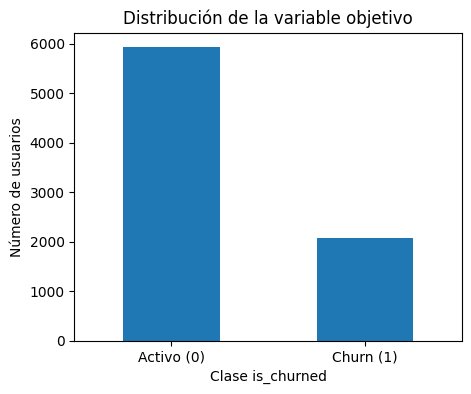

In [ ]:
target = "is_churned"
id_column = "user_id"

numeric_features = [
    "age",
    "listening_time",
    "songs_played_per_day",
    "skip_rate",
    "ads_listened_per_week"
]

categorical_features = [
    "gender",
    "country",
    "subscription_type",
    "device_type"
]

binary_features = ["offline_listening"]

feature_columns = numeric_features + categorical_features + binary_features

print("Variable objetivo:", target)
print("Identificador excluido:", id_column)
print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Variables binarias:", binary_features)

# Distribución de la variable objetivo (clase desbalanceada: 74% activos, 26% churn)
target_counts = df[target].value_counts().sort_index()
target_percent = df[target].value_counts(normalize=True).sort_index() * 100
target_summary = pd.DataFrame({
    "conteo": target_counts,
    "porcentaje": target_percent.round(2)
})
target_summary.index = ["Activo (0)", "Churn (1)"]
target_summary

# Gráfico de barras
ax = target_counts.plot(kind="bar", figsize=(5, 4))
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase is_churned")
ax.set_ylabel("Número de usuarios")
ax.set_xticklabels(["Activo (0)", "Churn (1)"], rotation=0)
plt.show()

# 5. Análisis descriptivo inicial

In [ ]:
# Estadísticas de las variables numéricas
df[numeric_features].describe().T

# Distribución de las variables categóricas
for col in categorical_features + binary_features:
    display(pd.DataFrame({
        "conteo": df[col].value_counts(dropna=False),
        "porcentaje": (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    }))

# 6. Análisis individual de variables frente al churn

In [ ]:
# Comparación de medias por clase para variables numéricas
mean_by_class = df.groupby(target)[numeric_features].mean().T
mean_by_class.columns = ["Activo (0)", "Churn (1)"]
mean_by_class["diferencia_churn_activo"] = mean_by_class["Churn (1)"] - mean_by_class["Activo (0)"]
mean_by_class.round(3)

# Prueba t de Student (diferencia de medias) para cada variable numérica
def cohens_d(x0, x1):
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)
    n0, n1 = len(x0), len(x1)
    s0, s1 = np.var(x0, ddof=1), np.var(x1, ddof=1)
    pooled = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))
    if pooled == 0:
        return 0
    return (np.mean(x1) - np.mean(x0)) / pooled

numeric_tests = []
for col in numeric_features:
    group0 = df.loc[df[target] == 0, col]
    group1 = df.loc[df[target] == 1, col]
    stat, p_value = ttest_ind(group0, group1, equal_var=False)
    numeric_tests.append({
        "variable": col,
        "media_activo": group0.mean(),
        "media_churn": group1.mean(),
        "diferencia": group1.mean() - group0.mean(),
        "cohens_d": cohens_d(group0, group1),
        "p_value_ttest": p_value
    })
numeric_tests_df = pd.DataFrame(numeric_tests).sort_values("p_value_ttest")
numeric_tests_df.round(5)

# Prueba chi-cuadrado para variables categóricas
def cramers_v(confusion_table):
    chi2, _, _, _ = chi2_contingency(confusion_table)
    n = confusion_table.sum().sum()
    r, k = confusion_table.shape
    denominator = n * (min(k - 1, r - 1))
    if denominator == 0:
        return 0
    return np.sqrt(chi2 / denominator)

cat_tests = []
for col in categorical_features + binary_features:
    table = pd.crosstab(df[col], df[target])
    chi2, p_value, _, _ = chi2_contingency(table)
    churn_rate = (df.groupby(col)[target].mean() * 100).round(2)
    cat_tests.append({
        "variable": col,
        "chi2": chi2,
        "p_value_chi2": p_value,
        "cramers_v": cramers_v(table),
        "tasa_churn_min": churn_rate.min(),
        "tasa_churn_max": churn_rate.max()
    })
cat_tests_df = pd.DataFrame(cat_tests).sort_values("p_value_chi2")
cat_tests_df.round(5)

# Tasas de churn por categoría
for col in categorical_features + binary_features:
    churn_rate = (df.groupby(col)[target].mean() * 100).sort_values(ascending=False).round(2)
    print(f"\nTasa de churn por {col} (%):")
    print(churn_rate)


Tasa de churn por gender (%):
gender
Female    26.29
Other     26.19
Male      25.20
Name: is_churned, dtype: float64

Tasa de churn por country (%):
country
PK    27.53
DE    27.29
FR    27.20
AU    25.73
US    25.39
CA    24.84
UK    24.74
IN    24.33
Name: is_churned, dtype: float64

Tasa de churn por subscription_type (%):
subscription_type
Family     27.52
Student    26.19
Premium    25.06
Free       24.93
Name: is_churned, dtype: float64

Tasa de churn por device_type (%):
device_type
Mobile     26.89
Desktop    25.74
Web        25.05
Name: is_churned, dtype: float64

Tasa de churn por offline_listening (%):
offline_listening
1    26.21
0    24.93
Name: is_churned, dtype: float64


# Conclusiones de la preparación inicial (resumen en markdown)

# 7. Preprocesamiento y partición de datos

In [ ]:
X = df[feature_columns].copy()
y = df[target].copy()

# División estratificada para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("Distribución y_train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True).round(4))

# Preprocesador: escalado para numéricas, one-hot para categóricas (drop='first' evita dummy trap)
def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", build_one_hot_encoder(), categorical_features),
        ("bin", "passthrough", binary_features),
    ],
    remainder="drop"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Métricas a evaluar
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

Tamaño entrenamiento: (6400, 10)
Tamaño test: (1600, 10)
Distribución y_train:
is_churned
0    0.7411
1    0.2589
Name: proportion, dtype: float64

Distribución y_test:
is_churned
0    0.7412
1    0.2588
Name: proportion, dtype: float64


# 8. Entrenamiento y evaluación de modelos base
Se comparan 5 modelos: Regresión Logística, KNN, Random Forest, MLP, SVM. La métrica principal de selección es F1-score por el desbalance de clases.


Entrenando Logistic Regression...

Entrenando KNN...

Entrenando Random Forest...

Entrenando MLP...

Entrenando SVM...
Dos mejores modelos según F1-CV: ['Logistic Regression', 'SVM']
Logistic Regression
              precision    recall  f1-score   support

      Activo       0.75      0.53      0.62      1186
       Churn       0.27      0.49      0.34       414

    accuracy                           0.52      1600
   macro avg       0.51      0.51      0.48      1600
weighted avg       0.62      0.52      0.55      1600



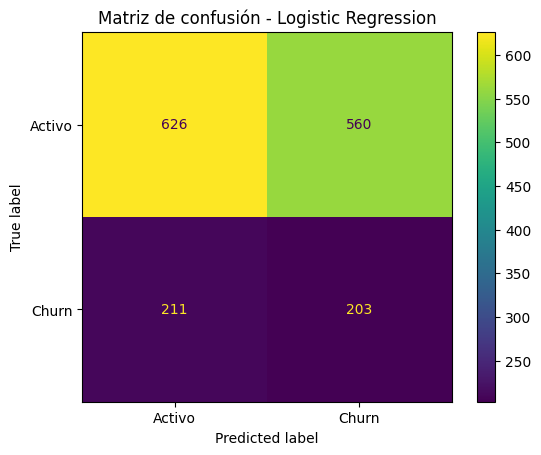

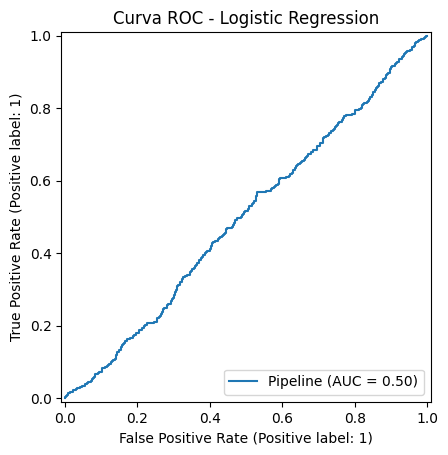

SVM
              precision    recall  f1-score   support

      Activo       0.76      0.55      0.64      1186
       Churn       0.28      0.50      0.36       414

    accuracy                           0.53      1600
   macro avg       0.52      0.52      0.50      1600
weighted avg       0.63      0.53      0.56      1600



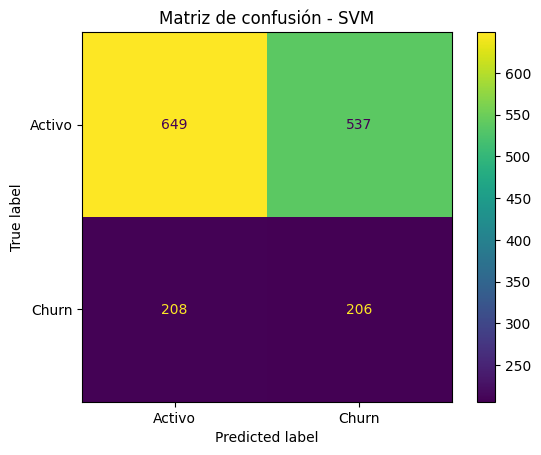

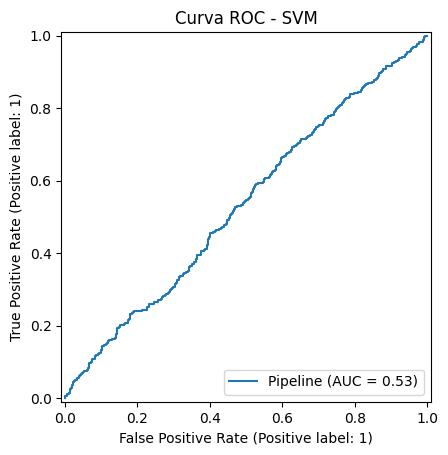

In [ ]:
model_spaces = {
    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",   # compensa desbalance
            solver="liblinear",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "param_grid": {
            "model__n_neighbors": [11, 21, 31, 51],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ),
        "param_grid": {
            "model__n_estimators": [200],
            "model__max_depth": [3, 5, 8, 12],
            "model__min_samples_leaf": [5, 10],
            "model__max_features": ["sqrt"],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },
    "MLP": {
        "estimator": MLPClassifier(
            max_iter=700,
            early_stopping=True,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "model__hidden_layer_sizes": [(16,), (32,), (32, 16)],
            "model__alpha": [0.001, 0.01, 0.1],
            "model__learning_rate_init": [0.001]
        }
    },
    "SVM": {
        "estimator": SVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf"],
            "model__gamma": ["scale", 0.01, 0.1]
        }
    }
}

# Función auxiliar para obtener scores (probabilidades o función de decisión)
def get_scores(estimator, X_data):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_data)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_data)
    return None

def evaluate_best_estimator(estimator, X_train, y_train, X_test, y_test):
    y_pred_train = estimator.predict(X_train)
    y_pred_test = estimator.predict(X_test)
    y_score_test = get_scores(estimator, X_test)

    result = {
        "f1_train": f1_score(y_train, y_pred_train, zero_division=0),
        "accuracy_test": accuracy_score(y_test, y_pred_test),
        "precision_test": precision_score(y_test, y_pred_test, zero_division=0),
        "recall_test": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_test": f1_score(y_test, y_pred_test, zero_division=0),
    }
    if y_score_test is not None:
        result["roc_auc_test"] = roc_auc_score(y_test, y_score_test)
    else:
        result["roc_auc_test"] = np.nan
    return result

def summarize_grid_search(model_name, grid, X_train, y_train, X_test, y_test, cv_splits=5):
    best_idx = grid.best_index_
    cv_results = grid.cv_results_

    f1_cv_mean = cv_results["mean_test_f1"][best_idx]
    f1_cv_std = cv_results["std_test_f1"][best_idx]
    f1_cv_ci95 = 1.96 * f1_cv_std / math.sqrt(cv_splits)

    test_metrics = evaluate_best_estimator(grid.best_estimator_, X_train, y_train, X_test, y_test)

    summary = {
        "model": model_name,
        "best_params": grid.best_params_,
        "f1_cv_mean": f1_cv_mean,
        "f1_cv_std": f1_cv_std,
        "f1_cv_ci95": f1_cv_ci95,
        "accuracy_cv_mean": cv_results["mean_test_accuracy"][best_idx],
        "precision_cv_mean": cv_results["mean_test_precision"][best_idx],
        "recall_cv_mean": cv_results["mean_test_recall"][best_idx],
        "roc_auc_cv_mean": cv_results["mean_test_roc_auc"][best_idx],
    }
    summary.update(test_metrics)
    return summary

trained_models = {}
base_results = []

# Entrenamiento con GridSearchCV (búsqueda de hiperparámetros, optimizando F1)
for model_name, cfg in model_spaces.items():
    print(f"\nEntrenando {model_name}...")
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", cfg["estimator"])
    ])
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=cfg["param_grid"],
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=N_JOBS,
        return_train_score=True,
        verbose=0
    )
    grid.fit(X_train, y_train)
    trained_models[model_name] = grid
    base_results.append(summarize_grid_search(model_name, grid, X_train, y_train, X_test, y_test, cv_splits=cv.get_n_splits()))

base_results_df = pd.DataFrame(base_results).sort_values("f1_cv_mean", ascending=False).reset_index(drop=True)
base_results_df

# Reporte detallado de los dos mejores modelos base
top2_base_models = base_results_df.head(2)["model"].tolist()
print("Dos mejores modelos según F1-CV:", top2_base_models)

for model_name in top2_base_models:
    print("=" * 80)
    print(model_name)
    best_estimator = trained_models[model_name].best_estimator_
    y_pred = best_estimator.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["Activo", "Churn"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Activo", "Churn"])
    disp.plot(values_format="d")
    plt.title(f"Matriz de confusión - {model_name}")
    plt.show()

    if get_scores(best_estimator, X_test) is not None:
        RocCurveDisplay.from_estimator(best_estimator, X_test, y_test)
        plt.title(f"Curva ROC - {model_name}")
        plt.show()

# 9. Experimento adicional: SMOTE moderado
Se prueba un sobremuestreo moderado (sampling_strategy=0.50) para manejar el desbalance, en lugar de balance 1:1. Esto se aplica dentro de un pipeline de imblearn.

In [ ]:
SMOTE_STRATEGY = 0.50

smote_model_spaces = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
        "param_grid": {"model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l1", "l2"]}
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "param_grid": {"model__n_neighbors": [21, 31, 51, 75], "model__weights": ["uniform", "distance"], "model__p": [1, 2]}
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "param_grid": {"model__n_estimators": [200], "model__max_depth": [3, 5, 8, 12], "model__min_samples_leaf": [5, 10], "model__max_features": ["sqrt"]}
    },
    "MLP": {
        "estimator": MLPClassifier(max_iter=700, early_stopping=True, random_state=RANDOM_STATE),
        "param_grid": {"model__hidden_layer_sizes": [(16,), (32,), (32, 16)], "model__alpha": [0.001, 0.01, 0.1], "model__learning_rate_init": [0.001]}
    },
    "SVM": {
        "estimator": SVC(random_state=RANDOM_STATE),
        "param_grid": {"model__C": [0.1, 1, 10], "model__kernel": ["rbf"], "model__gamma": ["scale", 0.01, 0.1]}
    }
}

trained_smote_models = {}
smote_results = []

for model_name, cfg in smote_model_spaces.items():
    print(f"\nEntrenando {model_name} con SMOTE moderado...")
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(sampling_strategy=SMOTE_STRATEGY, k_neighbors=5, random_state=RANDOM_STATE)),
        ("model", cfg["estimator"])
    ])
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=cfg["param_grid"],
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=N_JOBS,
        return_train_score=True,
        verbose=0
    )
    grid.fit(X_train, y_train)
    trained_smote_models[model_name] = grid
    smote_results.append(
        summarize_grid_search(
            f"{model_name} + SMOTE", grid, X_train, y_train, X_test, y_test, cv_splits=cv.get_n_splits()
        )
    )

smote_results_df = pd.DataFrame(smote_results).sort_values("f1_cv_mean", ascending=False).reset_index(drop=True)
smote_results_df

# Comparativa base vs SMOTE moderado
base_vs_smote = pd.concat([
    base_results_df.assign(experiment="Base"),
    smote_results_df.assign(experiment="SMOTE moderado")
], ignore_index=True, sort=False)

base_vs_smote[[
    "experiment", "model", "f1_cv_mean", "f1_cv_ci95",
    "f1_train", "f1_test", "recall_test", "precision_test",
    "accuracy_test", "roc_auc_test", "best_params"
]].sort_values(["f1_cv_mean", "f1_test"], ascending=False).reset_index(drop=True)


Entrenando Logistic Regression con SMOTE moderado...

Entrenando KNN con SMOTE moderado...


# 9.1. Ajuste de umbral para los mejores modelos

Se ajusta el umbral de decisión sobre los scores de validación cruzada para maximizar F1, sin usar el conjunto de test (solo entrenamiento + CV). Esto puede mejorar el recall de la clase churn.

In [ ]:
def get_cv_decision_scores(estimator, X_data, y_data, cv):
    if hasattr(estimator, "predict_proba"):
        try:
            return cross_val_predict(
                estimator, X_data, y_data, cv=cv, method="predict_proba", n_jobs=N_JOBS
            )[:, 1]
        except Exception:
            pass
    return cross_val_predict(
        estimator, X_data, y_data, cv=cv, method="decision_function", n_jobs=N_JOBS
    )

def find_best_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_values = 2 * (precision * recall) / (precision + recall + 1e-12)
    valid_f1 = f1_values[:-1]  # el último punto no tiene threshold
    best_idx = int(np.nanargmax(valid_f1))
    return {
        "threshold": thresholds[best_idx],
        "f1_cv_threshold": valid_f1[best_idx],
        "precision_cv_threshold": precision[best_idx],
        "recall_cv_threshold": recall[best_idx]
    }

def evaluate_with_threshold(estimator, X_test, y_test, threshold):
    test_scores = get_scores(estimator, X_test)
    y_pred = (test_scores >= threshold).astype(int)
    return {
        "accuracy_test": accuracy_score(y_test, y_pred),
        "precision_test": precision_score(y_test, y_pred, zero_division=0),
        "recall_test": recall_score(y_test, y_pred, zero_division=0),
        "f1_test": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc_test": roc_auc_score(y_test, test_scores)
    }

# Registrar los mejores estimadores de los experimentos base y SMOTE
model_registry = {}
for model_name, grid in trained_models.items():
    model_registry[f"Base | {model_name}"] = grid.best_estimator_
for model_name, grid in trained_smote_models.items():
    model_registry[f"SMOTE moderado | {model_name}"] = grid.best_estimator_

threshold_candidates = base_vs_smote.copy()
threshold_candidates["registry_key"] = threshold_candidates.apply(
    lambda row: f"{row['experiment']} | {row['model'].replace(' + SMOTE', '')}", axis=1
)

# Tomar los 3 mejores según F1-CV y F1-test
top_threshold_candidates = threshold_candidates.sort_values(
    ["f1_cv_mean", "f1_test"], ascending=False
).head(3)

threshold_results = []
for _, row in top_threshold_candidates.iterrows():
    key = row["registry_key"]
    estimator = model_registry[key]
    print(f"\nBuscando umbral para: {key}")
    cv_scores = get_cv_decision_scores(estimator, X_train, y_train, cv)
    threshold_info = find_best_threshold(y_train, cv_scores)
    test_metrics = evaluate_with_threshold(estimator, X_test, y_test, threshold_info["threshold"])

    threshold_results.append({
        "model": f"{row['model']} + threshold",
        "source_experiment": row["experiment"],
        "threshold": threshold_info["threshold"],
        "f1_cv_mean": threshold_info["f1_cv_threshold"],
        "precision_cv_mean": threshold_info["precision_cv_threshold"],
        "recall_cv_mean": threshold_info["recall_cv_threshold"],
        **test_metrics
    })

threshold_results_df = pd.DataFrame(threshold_results).sort_values("f1_test", ascending=False).reset_index(drop=True)
threshold_results_df

# 10. Importancia de variables con Random Forest (interpretación)

In [ ]:
if "Random Forest" in trained_models:
    rf_best = trained_models["Random Forest"].best_estimator_
    rf_model = rf_best.named_steps["model"]
    rf_preprocessor = rf_best.named_steps["preprocess"]
    feature_names = rf_preprocessor.get_feature_names_out()
    importances = rf_model.feature_importances_
    importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
    display(importance_df.head(15))
    ax = importance_df.head(15).sort_values("importance").plot(kind="barh", x="feature", y="importance", figsize=(8, 6), legend=False)
    ax.set_title("Top 15 variables según Random Forest")
    ax.set_xlabel("Importancia")
    ax.set_ylabel("Variable")
    plt.show()

# 11. Reducción de dimensión con PCA
Se aplica PCA a los dos mejores modelos base, conservando el 95% de la varianza.

In [ ]:
def run_reduced_grid(model_name, reducer_name, reducer, extra_grid=None):
    cfg = model_spaces[model_name]
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("reducer", reducer),
        ("model", clone(cfg["estimator"]))
    ])
    param_grid = dict(cfg["param_grid"])
    if extra_grid:
        param_grid.update(extra_grid)
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=N_JOBS,
        return_train_score=True,
        verbose=0
    )
    grid.fit(X_train, y_train)
    result = summarize_grid_search(
        f"{model_name} + {reducer_name}", grid, X_train, y_train, X_test, y_test, cv_splits=cv.get_n_splits()
    )
    return grid, result

pca_models = {}
pca_results = []
for model_name in top2_base_models:
    print(f"\nEvaluando {model_name} con PCA...")
    pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
    grid, result = run_reduced_grid(model_name, "PCA", pca)
    fitted_preprocessor = grid.best_estimator_.named_steps["preprocess"]
    fitted_pca = grid.best_estimator_.named_steps["reducer"]
    n_original = len(fitted_preprocessor.get_feature_names_out())
    n_components = fitted_pca.n_components_
    reduction_pct = (1 - n_components / n_original) * 100
    result["original_features"] = n_original
    result["reduced_components"] = n_components
    result["reduction_pct"] = reduction_pct
    pca_models[model_name] = grid
    pca_results.append(result)

pca_results_df = pd.DataFrame(pca_results).sort_values("f1_cv_mean", ascending=False).reset_index(drop=True)
pca_results_df

# 12. Reducción de dimensión con UMAP
UMAP (reducción no lineal) con búsqueda de número de componentes (2,5,10) mediante validación cruzada.

In [ ]:
try:
    import umap.umap_ as umap
except ImportError:
    raise ImportError("Instala UMAP ejecutando: !pip install umap-learn")

umap_models = {}
umap_results = []
for model_name in top2_base_models:
    print(f"\nEvaluando {model_name} con UMAP...")
    reducer = umap.UMAP(random_state=RANDOM_STATE)
    extra_grid = {
        "reducer__n_components": [2, 5, 10],
        "reducer__n_neighbors": [15],
        "reducer__min_dist": [0.1]
    }
    grid, result = run_reduced_grid(model_name, "UMAP", reducer, extra_grid=extra_grid)
    fitted_preprocessor = grid.best_estimator_.named_steps["preprocess"]
    fitted_umap = grid.best_estimator_.named_steps["reducer"]
    n_original = len(fitted_preprocessor.get_feature_names_out())
    n_components = fitted_umap.n_components
    reduction_pct = (1 - n_components / n_original) * 100
    result["original_features"] = n_original
    result["reduced_components"] = n_components
    result["reduction_pct"] = reduction_pct
    umap_models[model_name] = grid
    umap_results.append(result)

umap_results_df = pd.DataFrame(umap_results).sort_values("f1_cv_mean", ascending=False).reset_index(drop=True)
umap_results_df

# 13. Comparación final de resultados

In [ ]:
all_results_df = pd.concat([
    base_results_df.assign(experiment="Base"),
    smote_results_df.assign(experiment="SMOTE moderado"),
    threshold_results_df.assign(experiment="Ajuste de umbral"),
    pca_results_df.assign(experiment="PCA"),
    umap_results_df.assign(experiment="UMAP")
], ignore_index=True, sort=False)

cols_to_show = [
    "experiment", "source_experiment", "model", "f1_cv_mean", "f1_cv_ci95", "f1_train",
    "f1_test", "recall_test", "precision_test", "accuracy_test", "roc_auc_test",
    "threshold", "reduced_components", "reduction_pct", "best_params"
]

final_comparison = all_results_df[[c for c in cols_to_show if c in all_results_df.columns]].sort_values(
    ["f1_cv_mean", "f1_test"], ascending=False
).reset_index(drop=True)

final_comparison

# Gráfico de barras comparativo de F1-test
plot_df = final_comparison.copy()
plot_df["label"] = plot_df["experiment"] + " - " + plot_df["model"]
ax = plot_df.sort_values("f1_test").plot(kind="barh", x="label", y="f1_test", figsize=(9, 6), legend=False)
ax.set_title("Comparación final según F1-score en test")
ax.set_xlabel("F1-score test")
ax.set_ylabel("Experimento - modelo")
plt.show()

## 14. Conclusiones finales del notebook

Completar después de ejecutar todo el notebook con base en `final_comparison`.

Aspectos que deben discutirse en el informe:

- Mejor modelo base según F1-score de validación cruzada.
- Mejor modelo en test según F1-score y recall de la clase churn.
- Efecto del SMOTE moderado: si mejora recall/F1 y si reduce demasiado precisión, accuracy o AUC.
- Efecto del ajuste de umbral: si mejora la detección de churn sin modificar el entrenamiento.
- Señales de sobreajuste: diferencia entre F1 de entrenamiento y F1 de test.
- Comparación entre modelos base, SMOTE, PCA y UMAP.
- Si los AUC permanecen cerca de 0.5, interpretar que las variables disponibles tienen baja capacidad discriminativa para separar usuarios activos y usuarios en churn.
